In [59]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv("C:\\Users\\DEBABRATA\\Downloads\\archive (1)\\ai-impact-jobs-layoff-risk-dataset.csv")

In [61]:
#Phase 1: Data Exploration & Profiling (Understanding Your Data)

In [63]:
# Load raw dataset

In [64]:
df

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,56,Bachelor's,10,Retail,Sales Associate,Small,Entry,29,62,44,Low,0,4,16,0,Medium
19996,43,Bachelor's,9,Manufacturing,Production Supervisor,Medium,Entry,87,20,20,High,9,23,77,67,High
19997,28,High School,7,Telecom,Support Specialist,Medium,Entry,91,2,49,Medium,2,14,55,10,High
19998,46,Bachelor's,3,Manufacturing,Quality Engineer,Medium,Senior,76,40,89,Medium,3,13,66,5,Medium


In [65]:
# 2. Inspect the first 5 rows to understand the structure

In [66]:
print(df.head())

   Age Education_Level  Years_of_Experience       Industry  \
0   59        Master's                    6        Finance   
1   44        Master's                   14  Manufacturing   
2   36      Bachelor's                    7         Retail   
3   27      Bachelor's                    6        Finance   
4   49     High School                   12        Finance   

                Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
0             Accountant       Medium     Entry                       84   
1  Production Supervisor        Small     Entry                       30   
2          Store Manager       Medium    Senior                       12   
3                Auditor        Large     Entry                       90   
4                Auditor        Small     Entry                       49   

   Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
0                      21                       94            Medium   
1                      84 

In [67]:
# 3. Check data types, row counts, and discover missing values

In [68]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [69]:
# 4. Generate summary statistics for numeric metrics

In [70]:
print(df.describe())

                Age  Years_of_Experience  Routine_Task_Percentage  \
count  20000.000000         20000.000000             20000.000000   
mean      40.361500             7.265500                51.885500   
std       11.526333             4.720606                24.437808   
min       21.000000             0.000000                10.000000   
25%       30.000000             4.000000                31.000000   
50%       40.000000             7.000000                52.000000   
75%       50.000000            11.000000                73.000000   
max       60.000000            32.000000                94.000000   

       Creativity_Requirement  Human_Interaction_Level  \
count            20000.000000             20000.000000   
mean                47.786700                60.055000   
std                 26.100482                22.267801   
min                  0.000000                20.000000   
25%                 27.000000                41.000000   
50%                 48.000000 

In [71]:
#Phase 2: Data Cleaning & Validation (Sanitizing the Data) 

In [72]:
# 1. Check for missing values across all columns

In [73]:
print(df.isnull().sum())

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64


In [74]:
# 2. Count duplicate records

In [75]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

Total duplicate rows found: 0


In [76]:
# 3. Clean duplicates out of your working environment (if any exist)

In [77]:
df = df.drop_duplicates()

In [78]:
#Phase 3: Strategic Aggregation & Exploratory Analysis (Extracting Insights)

In [79]:
# 1. Cross-tabulate Layoff Risk by Industry to find percentages

In [80]:
industry_distribution = pd.crosstab(df['Industry'], df['Layoff_Risk'], normalize='index') * 100
print("--- Industry Layoff Risk Breakdown (%) ---")
print(industry_distribution)

--- Industry Layoff Risk Breakdown (%) ---
Layoff_Risk         High        Low     Medium
Industry                                      
Education      20.089833  48.427930  31.482238
Finance        37.723836  27.298050  34.978114
Healthcare     20.773135  47.403358  31.823506
IT             27.950060  38.179621  33.870318
Logistics      41.519293  25.000000  33.480707
Manufacturing  48.229548  19.454619  32.315832
Retail         40.737738  25.050669  34.211593
Telecom        35.166538  32.920217  31.913246


In [81]:
# 2. Aggregate structural workplace metrics by Risk level

In [82]:
risk_drivers = df.groupby('Layoff_Risk')[['Routine_Task_Percentage', 'Creativity_Requirement', 'Tasks_Automated_Percentage']].mean()
print("\n--- Core Drivers of Layoff Risk Level (Means) ---")
print(risk_drivers)


--- Core Drivers of Layoff Risk Level (Means) ---
             Routine_Task_Percentage  Creativity_Requirement  \
Layoff_Risk                                                    
High                       75.172870               23.844343   
Low                        28.540139               71.926840   
Medium                     51.255567               48.296167   

             Tasks_Automated_Percentage  
Layoff_Risk                              
High                          55.957334  
Low                           19.451227  
Medium                        35.724890  


In [83]:
#Phase 4: Deep Data Profiling & Structural Auditing

In [84]:
# 1. Audit categorical column unique values (Check for typos/variations)

In [85]:
categorical_cols = ['Education_Level', 'Industry', 'Job_Level', 'AI_Adoption_Level', 'Layoff_Risk']
for col in categorical_cols:
    print(f"--- Unique values in {col} ---")
    print(df[col].value_counts(dropna=False))
    print("-" * 30)

--- Unique values in Education_Level ---
Education_Level
Bachelor's     9967
Master's       5426
High School    3558
PhD            1049
Name: count, dtype: int64
------------------------------
--- Unique values in Industry ---
Industry
Telecom          2582
Healthcare       2561
Finance          2513
Logistics        2488
IT               2483
Retail           2467
Manufacturing    2457
Education        2449
Name: count, dtype: int64
------------------------------
--- Unique values in Job_Level ---
Job_Level
Entry     9016
Mid       7940
Senior    3044
Name: count, dtype: int64
------------------------------
--- Unique values in AI_Adoption_Level ---
AI_Adoption_Level
Low       10539
Medium     8046
High       1415
Name: count, dtype: int64
------------------------------
--- Unique values in Layoff_Risk ---
Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64
------------------------------


In [86]:
# 2. Check for out-of-bounds metrics (e.g., percentages > 100 or negative hours)

In [87]:
print("\n--- Out of Bounds Auditing ---")
print("Max Routine Task %:", df['Routine_Task_Percentage'].max())
print("Min AI Training Hours:", df['AI_Training_Hours'].min())
print("Max Tasks Automated %:", df['Tasks_Automated_Percentage'].max())


--- Out of Bounds Auditing ---
Max Routine Task %: 94
Min AI Training Hours: 0
Max Tasks Automated %: 93


In [88]:
#Phase 5: Advanced Feature Engineering & Data Preparation

In [89]:
# 1. Create a conditional feature: High Automation Risk flag
# Rule: If automated tasks > 50% AND routine task percentage > 70%

In [90]:
df['High_Automation_Exposure'] = np.where(
    (df['Tasks_Automated_Percentage'] > 50) & (df['Routine_Task_Percentage'] > 70), 
    'Highly Exposed', 
    'Stable'
)

In [91]:
# 2. Convert text classifications to ordered numbers for modeling/advanced analytics

In [92]:
risk_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['Layoff_Risk_Score'] = df['Layoff_Risk'].map(risk_mapping)

print(df[['Job_Role', 'High_Automation_Exposure', 'Layoff_Risk_Score']].head())

                Job_Role High_Automation_Exposure  Layoff_Risk_Score
0             Accountant                   Stable                  3
1  Production Supervisor                   Stable                  1
2          Store Manager                   Stable                  1
3                Auditor           Highly Exposed                  3
4                Auditor                   Stable                  2


In [93]:
#Phase 6: Segmented Deep-Dive Analytics

In [94]:
# 1. Evaluate average automation levels across Job Levels combined with Industry

In [95]:
pivot_insights = df.pivot_table(
    values='Tasks_Automated_Percentage', 
    index='Industry', 
    columns='Job_Level', 
    aggfunc='mean'
).round(2)

print("--- Avg Tasks Automated % by Industry and Job Level ---")
print(pivot_insights)

--- Avg Tasks Automated % by Industry and Job Level ---
Job_Level      Entry    Mid  Senior
Industry                           
Education      37.67  37.48   38.47
Finance        37.79  37.04   38.06
Healthcare     36.84  37.36   36.36
IT             38.38  36.78   36.34
Logistics      37.89  36.23   38.27
Manufacturing  37.48  38.73   37.43
Retail         35.97  36.04   37.20
Telecom        37.14  36.82   35.83


In [96]:
# 2. Correlate numerical features to discover direct triggers

In [97]:
correlation_matrix = df[['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 
                         'Creativity_Requirement', 'Tasks_Automated_Percentage', 
                         'AI_Usage_Hours_Per_Week']].corr()
print("\n--- Numerical Correlation Matrix ---")
print(correlation_matrix['Tasks_Automated_Percentage'])


--- Numerical Correlation Matrix ---
Age                          -0.000609
Years_of_Experience          -0.004052
Routine_Task_Percentage       0.890177
Creativity_Requirement       -0.827417
Tasks_Automated_Percentage    1.000000
AI_Usage_Hours_Per_Week       0.597428
Name: Tasks_Automated_Percentage, dtype: float64


In [98]:
#Phase 7:Graphical representation

In [106]:
# A. Simple Bar Chart (Layoff Risk Counts)
# Set visual style

In [107]:
sns.set_theme(style="whitegrid")

In [108]:
# Create a simple vertical bar chart

C:\Users\DEBABRATA\AppData\Local\Temp\ipykernel_51188\1842284260.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Layoff_Risk', order=['Low', 'Medium', 'High'], palette='viridis')


<Axes: xlabel='Layoff_Risk', ylabel='count'>

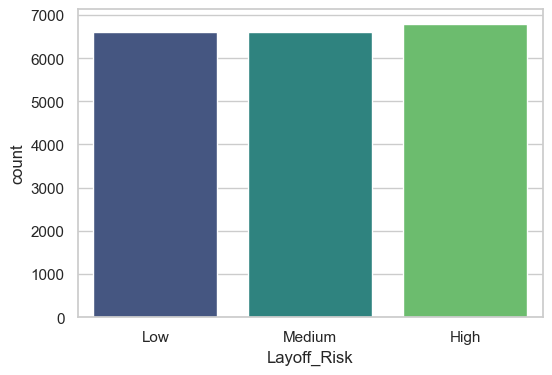

In [122]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Layoff_Risk', order=['Low', 'Medium', 'High'], palette='viridis')

In [111]:
# Add titles and labels

Text(0, 0.5, 'Number of Employees')

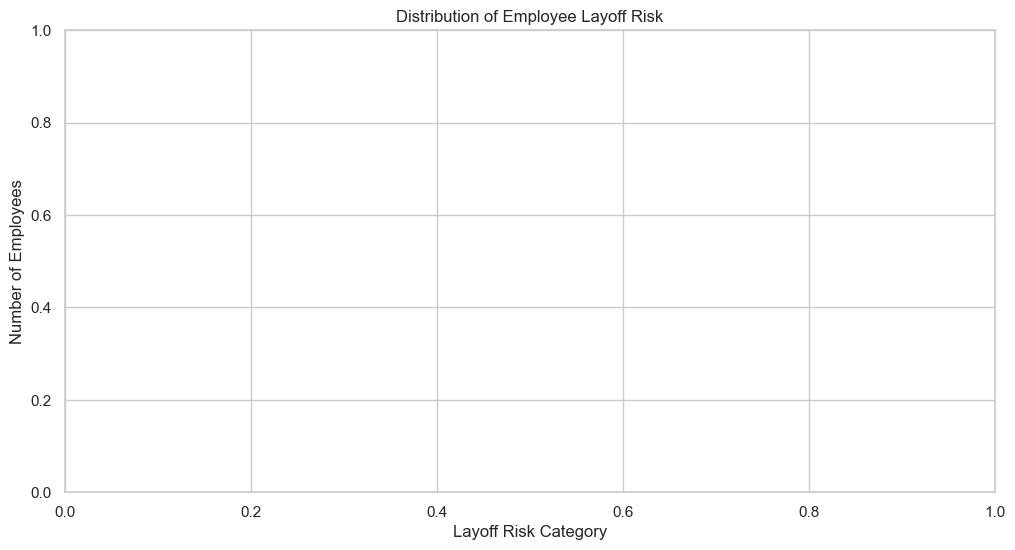

In [123]:
plt.title('Distribution of Employee Layoff Risk')
plt.xlabel('Layoff Risk Category')
plt.ylabel('Number of Employees')

In [124]:
# Show the graph on screen

In [125]:
plt.show()

In [126]:
# B. Simple Scatter Plot (Routine Tasks vs. Automation %)

In [127]:
plt.figure(figsize=(7, 5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

In [128]:
# Create a scatter plot colored by Layoff Risk

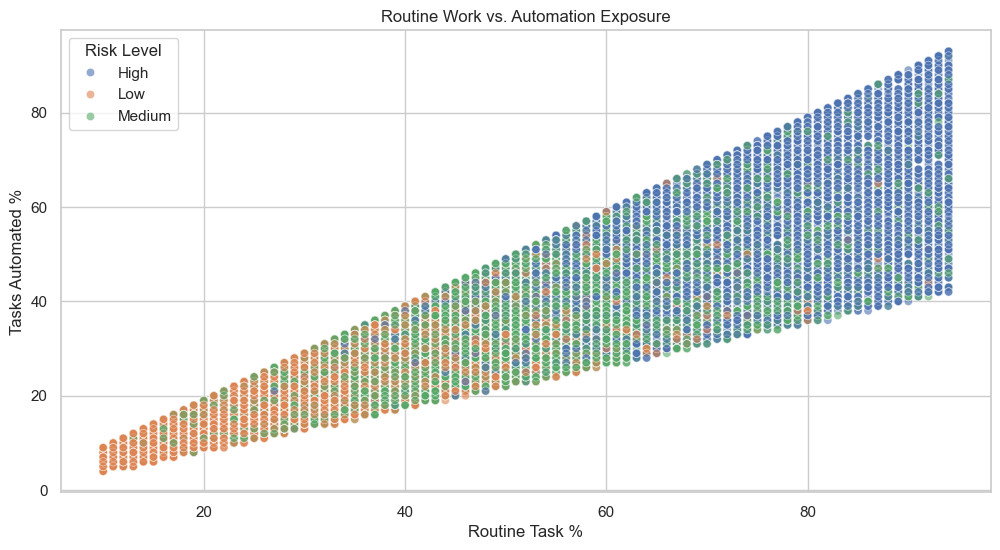

In [129]:
sns.scatterplot(
    data=df, 
    x='Routine_Task_Percentage', 
    y='Tasks_Automated_Percentage', 
    hue='Layoff_Risk', 
    alpha=0.6
)

plt.title('Routine Work vs. Automation Exposure')
plt.xlabel('Routine Task %')
plt.ylabel('Tasks Automated %')
plt.legend(title='Risk Level')

plt.show()